In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


Train Shape:  (1460, 81)
Test Shape:  (1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  Ove

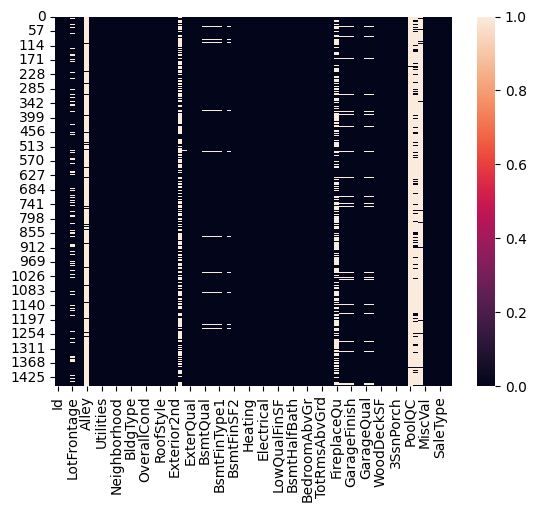

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


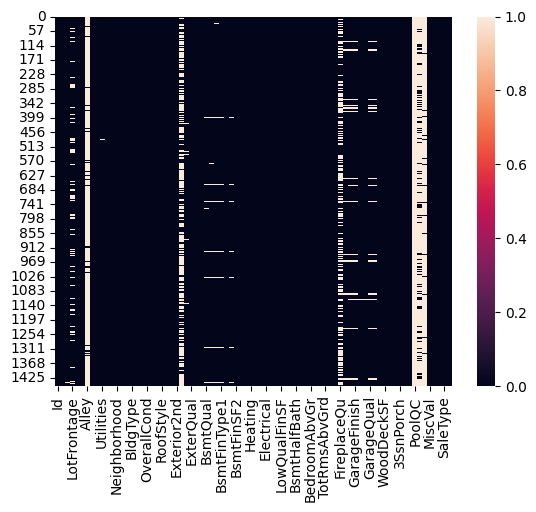

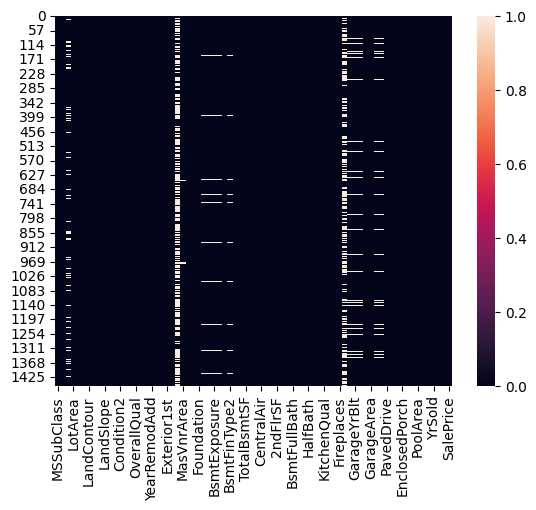

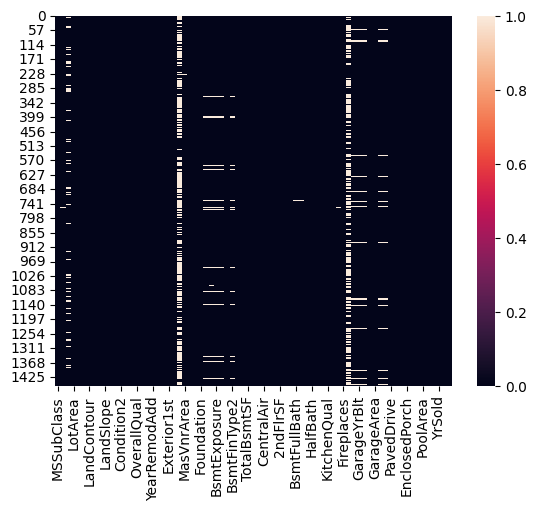

Train Shape (sau khi cắt):  (1458, 76)
Test Shape (sau khi cắt):  (1459, 75)
MSZoning
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinType2
Heating
HeatingQC
CentralAir
Electrical
KitchenQual
Functional
FireplaceQu
GarageType
GarageFinish
GarageQual
GarageCond
PavedDrive
SaleType
SaleCondition
Shape sau khi gộp:  (2917, 176)

Đang chạy XGBoost...
Đang chạy LightGBM...

Hoàn tất 100%! Hãy nộp file 'submission_master.csv' để kiểm tra thứ hạng trên Leaderboard.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# PHẦN 1: NẠP DỮ LIỆU & IN DANH SÁCH (NGUYÊN BẢN PDF)
# ==========================================
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

print("Train Shape: ", train.shape)
print("Test Shape: ", test.shape)

# In danh sách chứa kiểu dữ liệu
print(train.info())
print(test.info())

# In danh sách đếm số lượng Null và vẽ Biểu đồ 1 & 2
print(train.isnull().sum())
sns.heatmap(train.isnull())
plt.show()

print(test.isnull().sum())
sns.heatmap(test.isnull())
plt.show()

# --- TUYỆT CHIÊU KAGGLE: LOẠI BỎ NGOẠI LỆ ---
# Loại bỏ các căn nhà có diện tích lớn bất thường gây nhiễu AI
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)
train = train.reset_index(drop=True)

# ==========================================
# PHẦN 2: XÓA CỘT LỖI & VẼ BIỂU ĐỒ 3 & 4
# ==========================================
test_id = test['Id']
y_train_raw = train['SalePrice']

to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']
train.drop(columns=to_drop, inplace=True)
test.drop(columns=to_drop, inplace=True)

# Vẽ biểu đồ 3 & 4 sau khi xóa cột
sns.heatmap(train.isnull())
plt.show()

sns.heatmap(test.isnull())
plt.show()

print("Train Shape (sau khi cắt): ", train.shape)
print("Test Shape (sau khi cắt): ", test.shape)

# ==========================================
# PHẦN 3: TỐI ƯU HÓA DỮ LIỆU (Median + Feature Engineering)
# ==========================================
train_no_price = train.drop(['SalePrice'], axis=1)
final_df = pd.concat([train_no_price, test], axis=0).reset_index(drop=True)

# Điền khuyết bằng Median và Mode để chống nhiễu
for col in final_df.select_dtypes(include=['object']).columns:
    final_df[col] = final_df[col].fillna(final_df[col].mode()[0])
for col in final_df.select_dtypes(exclude=['object']).columns:
    final_df[col] = final_df[col].fillna(final_df[col].median())

# Tạo đặc trưng mới giúp AI "hiểu" tổng diện tích
final_df['TotalSF'] = final_df['TotalBsmtSF'] + final_df['1stFlrSF'] + final_df['2ndFlrSF']
final_df['TotalBathrooms'] = final_df['FullBath'] + (0.5 * final_df['HalfBath']) + final_df['BsmtFullBath'] + (0.5 * final_df['BsmtHalfBath'])

# ==========================================
# PHẦN 4: ONE-HOT ENCODING (In tên các cột)
# ==========================================
all_cat_col = final_df.select_dtypes(include=['object']).columns.tolist()

def cat_onehot_encoding(multicol):
    df_final = final_df
    i = 0
    for fields in multicol:
        print(fields) 
        df1 = pd.get_dummies(final_df[fields], drop_first=True)
        final_df.drop([fields], axis=1, inplace=True)
        if i == 0:
            df_final = df1.copy()
        else:
            df_final = pd.concat([df_final, df1], axis=1)
        i = i + 1
    df_final = pd.concat([final_df, df_final], axis=1)
    return df_final

final_df = cat_onehot_encoding(all_cat_col)
final_df = final_df.loc[:, ~final_df.columns.duplicated()]

print("Shape sau khi gộp: ", final_df.shape)

# Chia tách tập dữ liệu
df_train = final_df.iloc[:len(train), :].copy()
df_test = final_df.iloc[len(train):, :].copy()

# ==========================================
# PHẦN 5: HUẤN LUYỆN TRỘN MÔ HÌNH BẢN PRO
# ==========================================
y_train = np.log1p(y_train_raw)

print("\nĐang chạy XGBoost...")
model_xgb = xgb.XGBRegressor(learning_rate=0.01, max_depth=3, n_estimators=3500, subsample=0.7, colsample_bytree=0.7, random_state=42)
model_xgb.fit(df_train, y_train)

print("Đang chạy LightGBM...")
model_lgb = LGBMRegressor(learning_rate=0.01, max_depth=3, n_estimators=3500, subsample=0.7, colsample_bytree=0.7, random_state=42, verbose=-1)
model_lgb.fit(df_train, y_train)

# Xuất file nộp
pred_xgb = np.expm1(model_xgb.predict(df_test))
pred_lgb = np.expm1(model_lgb.predict(df_test))
final_pred = (pred_xgb + pred_lgb) / 2

sub_df = pd.DataFrame({'Id': test_id, 'SalePrice': final_pred})
sub_df.to_csv('submission.csv', index=False)
print("\nHoàn tất 100%! Hãy nộp file 'submission_master.csv' để kiểm tra thứ hạng trên Leaderboard.")